# act 10

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

In [ ]:
ticker = 'CL=F'

data = yf.download(ticker, start='2022-01-01', end='2025-04-07', progress=False)
close_prices = data['Close']

S0 = close_prices.iloc[-1]

S0

YF.download() has changed argument auto_adjust default to True


,2025-04-04
Ticker,
CL=F,61.990002


In [ ]:
returns = close_prices.pct_change().dropna()
sigma = returns.std() * np.sqrt(252)
T = 1
K = 65
num_steps = 252
r = 0.0425
n_sims = 10000
dt = T / num_steps
Z = np.random.normal(size=(n_sims, num_steps))

In [ ]:

def simulate_prices(S0, r, sigma, T, num_steps, n_sims):
    dt = T / num_steps
    Z = np.random.normal(size=(n_sims, num_steps)) ## parámetros estándar : 0 y 1
    simulated_returns = (r - 0.5 * sigma.iloc[0]**2) * dt + sigma.iloc[0] * np.sqrt(dt) * Z
    simulared_cumulative_returns = np.cumsum(simulated_returns, axis=1)
    simulated_prices = S0.iloc[0] * np.exp(simulared_cumulative_returns)
    return simulated_prices


def get_price__fixed_strike__average_price(simulated_prices, K, r, T, option_type):
    avg_prices = np.mean(simulated_prices[:, 1:], axis=1)

    if option_type == 'call':
        payoffs = np.maximum(avg_prices - K, 0)
    elif option_type == 'put':
        payoffs = np.maximum(K - avg_prices, 0)

    option_price =  np.exp(-r * T) * np.mean(payoffs)

    return option_price



def get_price__floating_strike__average_price(simulated_prices, K, r, T, option_type):
    avg_prices = np.mean(simulated_prices[:, 1:], axis=1)
    S_t= simulated_prices[:, -1]

    if option_type == 'call':
        payoffs = np.maximum(S_t - avg_prices, 0)
    elif option_type == 'put':
        payoffs = np.maximum(avg_prices - S_t, 0)

    option_price =  np.exp(-r * T) * np.mean(payoffs)
    return option_price


def get_price__fixed_strike__geometric_price(simulated_prices, K, r, T, option_type):
    geometric_mean = np.exp(np.mean(np.log(simulated_prices[:, 1:]), axis=1))

    if option_type == 'call':
        payoffs = np.maximum( geometric_mean- K, 0)
    elif option_type == 'put':
        payoffs = np.maximum(K - geometric_mean, 0)

    option_price =  np.exp(-r * T) * np.mean(payoffs)
    return option_price


def get_price__floating_strike__geometric_price(simulated_prices, K, r, T, option_type):
    S_t = simulated_prices[:, -1]
    geometric_mean = np.exp(np.mean(np.log(simulated_prices[:, 1:]), axis=1))

    if option_type == 'call':
        payoffs = np.maximum( geometric_mean- S_t, 0)
    elif option_type == 'put':
        payoffs = np.maximum(S_t - geometric_mean, 0)

    option_price =  np.exp(-r * T) * np.mean(payoffs)
    return option_price


def get_price__european(simulated_prices, K, r, T, option_type):
    S_t = simulated_prices[:, -1]

    if option_type == 'call':
        payoffs = np.maximum(S_t - K, 0)
    elif option_type == 'put':
        payoffs = np.maximum(K - S_t, 0)

    option_price =  np.exp(-r * T) * np.mean(payoffs)
    return option_price


In [ ]:
get_price__fixed_strike__average_price(simulated_prices, K, r, T, 'call')

np.float64(4.639598308071813)

In [ ]:
get_price__floating_strike__average_price(simulated_prices, K, r, T, 'call')

np.float64(5.862857510747503)

In [ ]:
get_price__fixed_strike__geometric_price(simulated_prices, K, r, T, 'call')

np.float64(4.322873962752897)

In [ ]:
get_price__floating_strike__geometric_price(simulated_prices, K, r, T, 'call')

np.float64(4.319086533072105)

In [ ]:
get_price__european(simulated_prices, K, r, T, 'call')

np.float64(9.174310176148385)

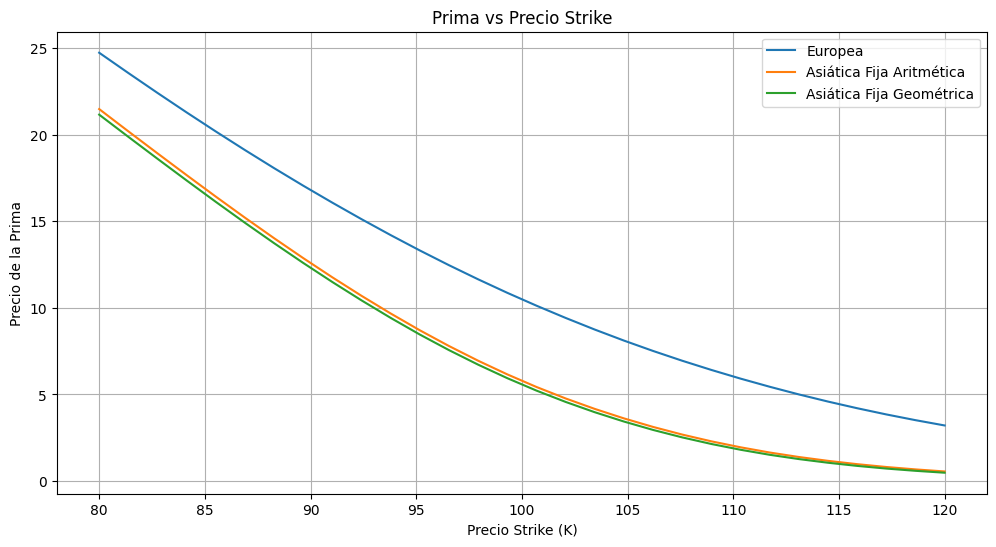

In [ ]:

def plot_option_prices_vs_strike():
    S0 = pd.Series([100])
    sigma = pd.Series([0.2])
    r = 0.05
    T = 1
    num_steps = 252
    n_sims = 10000
    option_type = 'call'

    simulated = simulate_prices(S0, r, sigma, T, num_steps, n_sims)
    S_t = simulated[:, -1]
    avg_arithmetic = np.mean(simulated[:, 1:], axis=1)
    avg_geometric = np.exp(np.mean(np.log(simulated[:, 1:]), axis=1))

    strikes = np.linspace(80, 120, 30)
    results = {
        "Europea": [],
        "Asiática Fija Aritmética": [],
        "Asiática Fija Geométrica": []
    }

    for K in strikes:
        european = np.maximum(S_t - K, 0)
        fixed_arith = np.maximum(avg_arithmetic - K, 0)
        fixed_geom = np.maximum(avg_geometric - K, 0)

        results["Europea"].append(np.exp(-r * T) * np.mean(european))
        results["Asiática Fija Aritmética"].append(np.exp(-r * T) * np.mean(fixed_arith))
        results["Asiática Fija Geométrica"].append(np.exp(-r * T) * np.mean(fixed_geom))

    plt.figure(figsize=(12, 6))
    for key, values in results.items():
        plt.plot(strikes, values, label=key)

    plt.title("Prima vs Precio Strike")
    plt.xlabel("Precio Strike (K)")
    plt.ylabel("Precio de la Prima")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_option_prices_vs_strike()


- ¿Cuáles son las más baratas y las más caras?

En orden de más cara a más barata:
  - europea
  - asiatica fija aritmetica
  - asiatica fija geometrica


- ¿Las más baratas sigue siendo la más baratas sin importar si es una opcion call o put?

si, no cambia

- Piensa por qué son estos resultados e interpreta lo que ves


3. Usando simulated prices, obtén el ST promedio.  Con ese ST, calcula los precios de las opciones Floating Strike. Compara los precios vs las Fixed Strike y la europea.

In [ ]:
S_T_avg = simulated_prices[:, -1].mean()
print(f"S_T promedio: {S_T_avg:.2f}")


S_T promedio: 65.04


In [ ]:
precio_flotante_arit = get_price__floating_strike__average_price(simulated_prices, S_T_avg, r, T, option_type='call')
precio_flotante_geom = get_price__floating_strike__geometric_price(simulated_prices, S_T_avg, r, T, option_type='call')
precio_flotante_arit


np.float64(6.143835516591773)

In [ ]:
precio_flotante_geom

np.float64(4.200838455192904)

In [ ]:
precio_fijo_arit = get_price__fixed_strike__average_price(simulated_prices, S_T_avg, r, T, option_type='call')
precio_fijo_geom = get_price__fixed_strike__geometric_price(simulated_prices, S_T_avg, r, T, option_type='call')
precio_europea = get_price__european(simulated_prices, S_T_avg, r, T, option_type='call')
precio_fijo_arit

np.float64(4.625864053566829)

In [ ]:
precio_fijo_geom

np.float64(4.242264187549626)

In [ ]:
precio_europea

np.float64(9.32912770349832)

- ¿Cuáles son las más baratas y las más caras?

la mas cara es la europea, seguida de la geometrica y luego la aritmetica

- ¿Las más baratas sigue siendo la más baratas sin importar si es una opcion call o put?

si porque las opciones con mayor riesgo tienden a ser mas caras

- Piensa por qué son estos resultados e interpreta lo que ves

la prima refleja el riesgo de cada una, siendo la europea la mas riesgosa, las opciones asiaticas tienden a ser menos riesgosas